# Classical ML Baselines
Sometimes simple models work surprisingly well!

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score, 
    f1_score,
    precision_recall_fscore_support
)
from sklearn.preprocessing import LabelEncoder
import joblib
import time
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# For XGBoost (install if needed)
try:
    import xgboost as xgb
    print("✅ XGBoost available")
except ImportError:
    print("⚠️  XGBoost not installed. Run: pip install xgboost")

print("✅ All libraries loaded!")

✅ XGBoost available
✅ All libraries loaded!


## Load and Prepare Data

In [2]:
# Load cleaned data
df = pd.read_csv('../data/customer_support_clean.csv')

print(f" Dataset shape: {df.shape}")
print(f" Number of categories: {df['category'].nunique()}")

# Check for any nulls
print(f"\n Missing values:\n{df.isnull().sum()}")

# Preview
df.head()

 Dataset shape: (26872, 4)
 Number of categories: 11

 Missing values:
instruction    0
response       0
category       0
intent         0
dtype: int64


,instruction,response,category,intent
0,question about cancelling order {{Order Number}},I've understood you have a question regarding ...,ORDER,cancel_order
1,i have a question about cancelling oorder {{Or...,I've been informed that you have a question ab...,ORDER,cancel_order
2,i need help cancelling puchase {{Order Number}},I can sense that you're seeking assistance wit...,ORDER,cancel_order
3,I need to cancel purchase {{Order Number}},I understood that you need assistance with can...,ORDER,cancel_order
4,"I cannot afford this order, cancel purchase {{...",I'm sensitive to the fact that you're facing f...,ORDER,cancel_order


## Prepare features and labels

In [3]:
# Features: customer queries (instructions)
X = df['instruction'].values

# Labels: categories we want to predict
y = df['category'].values

print(f"Features (X): {X.shape}")
print(f"Labels (y): {y.shape}")
print(f"\n Sample query: {X[0]}")
print(f" Sample label: {y[0]}")

Features (X): (26872,)
Labels (y): (26872,)

 Sample query: question about cancelling order {{Order Number}}
 Sample label: ORDER


## Encode labels to numbers

In [4]:
# ML models need numeric labels, not text
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"Labels encoded to numbers: 0 to {y_encoded.max()}")
print(f"\nExample mapping:")
for i in range(min(5, len(label_encoder.classes_))):
    print(f"  {label_encoder.classes_[i]} → {i}")

# Save encoder for later use
joblib.dump(label_encoder, '../models/label_encoder.pkl')
print("\n Label encoder saved to: models/label_encoder.pkl")

Labels encoded to numbers: 0 to 10

Example mapping:
  ACCOUNT → 0
  CANCEL → 1
  CONTACT → 2
  DELIVERY → 3
  FEEDBACK → 4

 Label encoder saved to: models/label_encoder.pkl


In [12]:
type(X)


pandas.arrays.ArrowStringArray

## Train/Validation/Test Split

In [13]:
# 70% train, 15% validation, 15% test
X_np = np.asarray(X)

X_temp, X_test, y_temp, y_test = train_test_split(
    X_np, y_encoded, 
    test_size=0.15, 
    random_state=42,
    stratify=y_encoded  # Keep same class distribution
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.176,  # 0.176 of 85% ≈ 15% of total
    random_state=42,
    stratify=y_temp
)

print("DATASET SPLITS")
print("=" * 60)
print(f"Training set:   {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation set: {len(X_val):,} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test set:       {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)")

# Verify class distribution is maintained
print(f"\nClass distribution check:")
print(f"Train: {Counter(y_train).most_common(3)}")
print(f"Val:   {Counter(y_val).most_common(3)}")
print(f"Test:  {Counter(y_test).most_common(3)}")

DATASET SPLITS
Training set:   18,820 samples (70.0%)
Validation set: 4,021 samples (15.0%)
Test set:       4,031 samples (15.0%)

Class distribution check:
Train: [(np.int64(0), 4192), (np.int64(6), 2793), (np.int64(8), 2095)]
Val:   [(np.int64(0), 896), (np.int64(6), 597), (np.int64(8), 448)]
Test:  [(np.int64(0), 898), (np.int64(6), 598), (np.int64(8), 449)]


## Feature Engineering - TF-IDF

In [14]:
print("Creating TF-IDF features...")

# TF-IDF: Term Frequency - Inverse Document Frequency
# Gives more weight to rare, informative words
tfidf = TfidfVectorizer(
    max_features=5000,      # Keep top 5000 words
    ngram_range=(1, 2),     # Use single words and pairs
    min_df=2,               # Word must appear in at least 2 documents
    max_df=0.95,            # Ignore words in >95% of documents
    stop_words='english'    # Remove common words like 'the', 'a'
)

# Fit on training data only!
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print(f" TF-IDF shape: {X_train_tfidf.shape}")
print(f"   Features: {X_train_tfidf.shape[1]:,} words/phrases")
print(f"   Sparsity: {(1 - X_train_tfidf.nnz / np.prod(X_train_tfidf.shape)) * 100:.1f}%")

# Save vectorizer
joblib.dump(tfidf, '../models/tfidf_vectorizer.pkl')
print("TF-IDF vectorizer saved")

Creating TF-IDF features...
 TF-IDF shape: (18820, 4806)
   Features: 4,806 words/phrases
   Sparsity: 99.8%
TF-IDF vectorizer saved


## Inspect top features

In [15]:
feature_names = tfidf.get_feature_names_out()
print(f"Sample features (words/phrases):")
print(feature_names[100:120])

# Show most common unigrams and bigrams
vocab = tfidf.vocabulary_
print(f"\n Vocabulary size: {len(vocab):,}")

Sample features (words/phrases):
['acquire article' 'acquire articles' 'acquire item' 'acquire items'
 'acquire product' 'acquire products' 'acquire ur' 'acquiring'
 'acquiring article' 'acquiring item' 'acquiring items'
 'acquiring product' 'acquiring ur' 'acvount' 'add' 'add article'
 'add articles' 'add damn' 'add goddamn' 'add item']

 Vocabulary size: 4,806


## Experiment 1A - Logistic Regression (Baseline)

In [16]:
print("EXPERIMENT 1A: Logistic Regression")
print("=" * 60)

start_time = time.time()

# Create and train model
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced',  # Handle class imbalance
    n_jobs=-1  # Use all CPU cores
)

lr_model.fit(X_train_tfidf, y_train)

train_time = time.time() - start_time

print(f"Training completed in {train_time:.2f} seconds")

# Predictions
y_val_pred = lr_model.predict(X_val_tfidf)

# Evaluate
accuracy = accuracy_score(y_val, y_val_pred)
f1_macro = f1_score(y_val, y_val_pred, average='macro')
f1_weighted = f1_score(y_val, y_val_pred, average='weighted')

print(f"\n VALIDATION RESULTS")
print(f"Accuracy:        {accuracy:.4f}")
print(f"F1 (Macro):      {f1_macro:.4f}")
print(f"F1 (Weighted):   {f1_weighted:.4f}")

# Save model
joblib.dump(lr_model, '../models/lr_tfidf.pkl')
print("\nModel saved to: models/lr_tfidf.pkl")

EXPERIMENT 1A: Logistic Regression
Training completed in 1.82 seconds

 VALIDATION RESULTS
Accuracy:        0.9960
F1 (Macro):      0.9955
F1 (Weighted):   0.9960

Model saved to: models/lr_tfidf.pkl


## Detailed classification report

In [20]:
print(" DETAILED CLASSIFICATION REPORT")
print("=" * 60)

# Get top 10 most common classes for detailed view
all_classes = Counter(y_val)
all_class_indices = [idx for idx in all_classes]

report = classification_report(
    y_val, 
    y_val_pred,
    target_names=label_encoder.classes_,
    digits=3
)
print(report)

 DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

     ACCOUNT      0.996     0.999     0.997       896
      CANCEL      0.993     0.993     0.993       142
     CONTACT      1.000     0.987     0.993       299
    DELIVERY      0.993     1.000     0.997       298
    FEEDBACK      0.997     1.000     0.998       299
     INVOICE      0.987     1.000     0.993       299
       ORDER      1.000     0.993     0.997       597
     PAYMENT      0.997     0.993     0.995       299
      REFUND      0.998     0.998     0.998       448
    SHIPPING      0.993     0.993     0.993       295
SUBSCRIPTION      1.000     0.993     0.997       149

    accuracy                          0.996      4021
   macro avg      0.996     0.995     0.996      4021
weighted avg      0.996     0.996     0.996      4021



## Confusion matrix for top categories

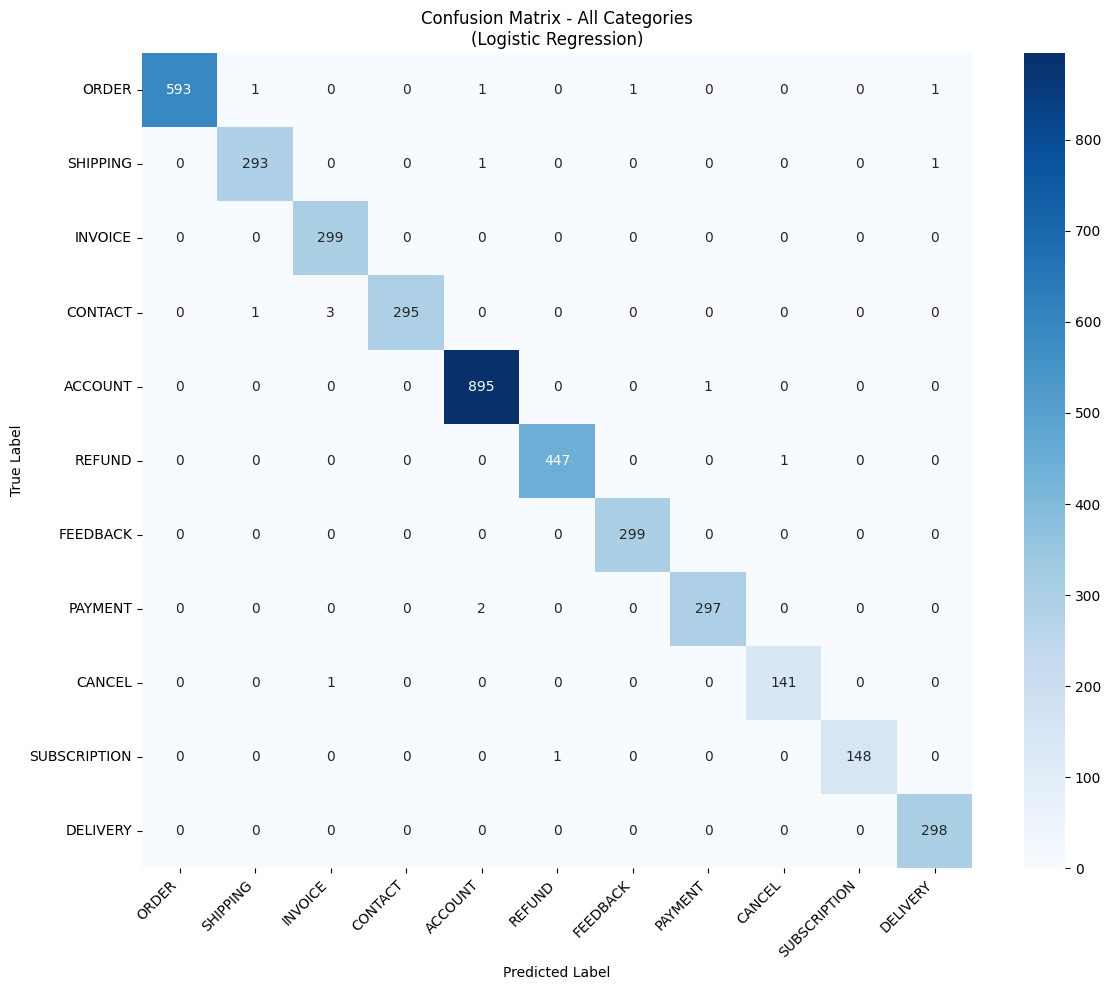

Confusion matrix saved to: experiments/lr_confusion_matrix.png


In [21]:
# Visualize where model makes mistakes
all_classes = label_encoder.inverse_transform(all_class_indices)

# Create confusion matrix
cm = confusion_matrix(y_val, y_val_pred, labels=all_class_indices)

# Plot
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=all_classes,
    yticklabels=all_classes
)
plt.title('Confusion Matrix - All Categories\n(Logistic Regression)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../experiments/lr_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("Confusion matrix saved to: experiments/lr_confusion_matrix.png")

## Experiment 1B - Random Forest

In [22]:
# Cell 11: Train Random Forest
print("EXPERIMENT 1B: Random Forest")
print("=" * 60)

start_time = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,        # Number of trees
    max_depth=30,            # Prevent overfitting
    min_samples_split=10,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_model.fit(X_train_tfidf, y_train)

train_time = time.time() - start_time

# Predictions
y_val_pred_rf = rf_model.predict(X_val_tfidf)

# Evaluate
accuracy_rf = accuracy_score(y_val, y_val_pred_rf)
f1_macro_rf = f1_score(y_val, y_val_pred_rf, average='macro')
f1_weighted_rf = f1_score(y_val, y_val_pred_rf, average='weighted')

print(f" Training completed in {train_time:.2f} seconds")
print(f"\n VALIDATION RESULTS")
print(f"Accuracy:        {accuracy_rf:.4f}")
print(f"F1 (Macro):      {f1_macro_rf:.4f}")
print(f"F1 (Weighted):   {f1_weighted_rf:.4f}")

# Save
joblib.dump(rf_model, '../models/rf_tfidf.pkl')

EXPERIMENT 1B: Random Forest
 Training completed in 2.18 seconds

 VALIDATION RESULTS
Accuracy:        0.9804
F1 (Macro):      0.9844
F1 (Weighted):   0.9802


['../models/rf_tfidf.pkl']

## Experiment 1C - XGBoost

In [23]:
print("EXPERIMENT 1C: XGBoost")
print("=" * 60)

start_time = time.time()

# Calculate class weights for imbalanced data
class_counts = Counter(y_train)
total_samples = len(y_train)
n_classes = len(class_counts)
class_weights = {
    cls: total_samples / (n_classes * count) 
    for cls, count in class_counts.items()
}

# Create sample weights
sample_weights = np.array([class_weights[cls] for cls in y_train])

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=7,
    learning_rate=0.1,
    random_state=42,
    tree_method='hist',  # Faster training
    n_jobs=-1
)

xgb_model.fit(
    X_train_tfidf, 
    y_train,
    sample_weight=sample_weights
)

train_time = time.time() - start_time

# Predictions
y_val_pred_xgb = xgb_model.predict(X_val_tfidf)

# Evaluate
accuracy_xgb = accuracy_score(y_val, y_val_pred_xgb)
f1_macro_xgb = f1_score(y_val, y_val_pred_xgb, average='macro')
f1_weighted_xgb = f1_score(y_val, y_val_pred_xgb, average='weighted')

print(f"Training completed in {train_time:.2f} seconds")
print(f"\nVALIDATION RESULTS")
print(f"Accuracy:        {accuracy_xgb:.4f}")
print(f"F1 (Macro):      {f1_macro_xgb:.4f}")
print(f"F1 (Weighted):   {f1_weighted_xgb:.4f}")

# Save
joblib.dump(xgb_model, '../models/xgb_tfidf.pkl')

EXPERIMENT 1C: XGBoost
Training completed in 41.81 seconds

VALIDATION RESULTS
Accuracy:        0.9935
F1 (Macro):      0.9933
F1 (Weighted):   0.9935


['../models/xgb_tfidf.pkl']

## Compare All Models

In [24]:
results = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [accuracy, accuracy_rf, accuracy_xgb],
    'F1 (Macro)': [f1_macro, f1_macro_rf, f1_macro_xgb],
    'F1 (Weighted)': [f1_weighted, f1_weighted_rf, f1_weighted_xgb]
}

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1 (Macro)', ascending=False)

print("MODEL COMPARISON (Validation Set)")
print("=" * 60)
print(results_df.to_string(index=False))

# Save results
results_df.to_csv('../experiments/phase1_results.csv', index=False)
print("\n Results saved to: experiments/phase1_results.csv")

MODEL COMPARISON (Validation Set)
              Model  Accuracy  F1 (Macro)  F1 (Weighted)
Logistic Regression  0.996021    0.995547       0.996020
            XGBoost  0.993534    0.993255       0.993534
      Random Forest  0.980353    0.984359       0.980204

 Results saved to: experiments/phase1_results.csv


## Visualize comparison

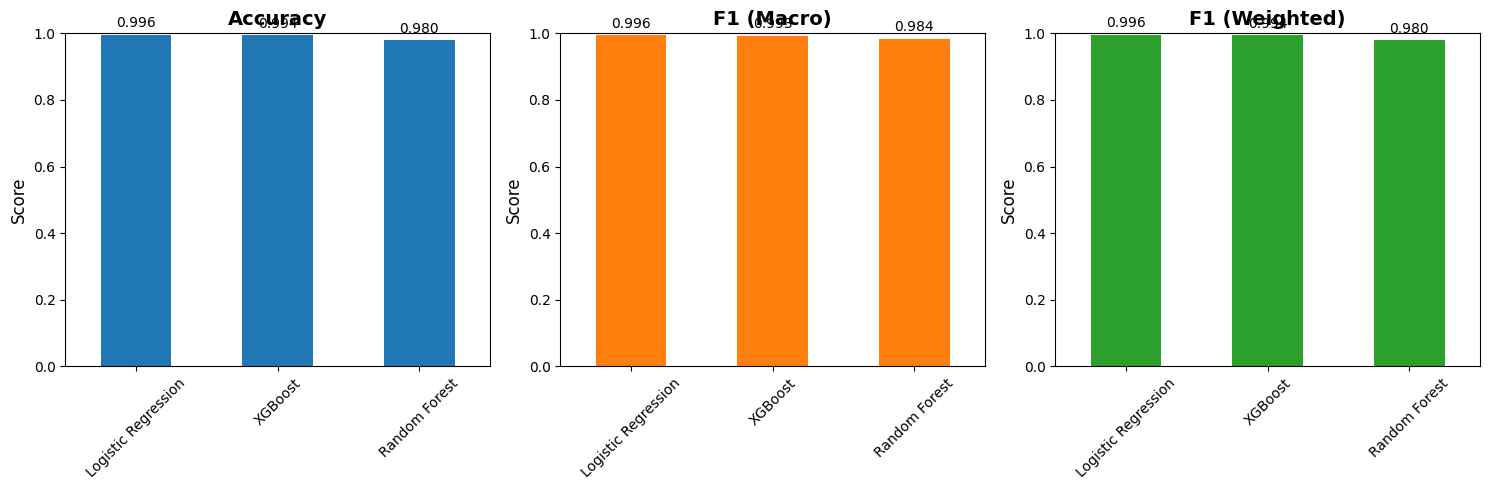

 Comparison chart saved to: experiments/phase1_comparison.png


In [25]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['Accuracy', 'F1 (Macro)', 'F1 (Weighted)']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for idx, metric in enumerate(metrics):
    results_df.plot(
        x='Model', 
        y=metric, 
        kind='bar', 
        ax=ax[idx],
        legend=False,
        color=colors[idx]
    )
    ax[idx].set_title(metric, fontsize=14, fontweight='bold')
    ax[idx].set_ylabel('Score', fontsize=12)
    ax[idx].set_xlabel('')
    ax[idx].set_ylim([0, 1])
    ax[idx].tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for container in ax[idx].containers:
        ax[idx].bar_label(container, fmt='%.3f', padding=3)

plt.tight_layout()
plt.savefig('../experiments/phase1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Comparison chart saved to: experiments/phase1_comparison.png")

## Error Analysis


In [43]:
# Analyze mistakes - which categories are hardest?
# Use best model (likely XGBoost or LR)
best_predictions = y_val_pred  # Change if another model is better

# Per-class F1 scores
precision, recall, f1, support = precision_recall_fscore_support(
    y_val, 
    best_predictions,
    labels=range(len(label_encoder.classes_))
)

# Create dataframe
error_analysis = pd.DataFrame({
    'Category': label_encoder.classes_,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})

# Sort by F1 score to find worst categories
error_analysis = error_analysis.sort_values('F1-Score')

print("CATEGORIES BY F1-SCORE")
print("=" * 60)
print(error_analysis.to_string(index=False))

# Save
error_analysis.to_csv('../experiments/per_category_performance.csv', index=False)

CATEGORIES BY F1-SCORE
    Category  Precision   Recall  F1-Score  Support
      CANCEL   0.992958 0.992958  0.992958      142
    SHIPPING   0.993220 0.993220  0.993220      295
     CONTACT   1.000000 0.986622  0.993266      299
     INVOICE   0.986799 1.000000  0.993355      299
     PAYMENT   0.996644 0.993311  0.994975      299
SUBSCRIPTION   1.000000 0.993289  0.996633      149
       ORDER   1.000000 0.993300  0.996639      597
    DELIVERY   0.993333 1.000000  0.996656      298
     ACCOUNT   0.995551 0.998884  0.997214      896
      REFUND   0.997768 0.997768  0.997768      448
    FEEDBACK   0.996667 1.000000  0.998331      299


## Visualize worst vs best categories


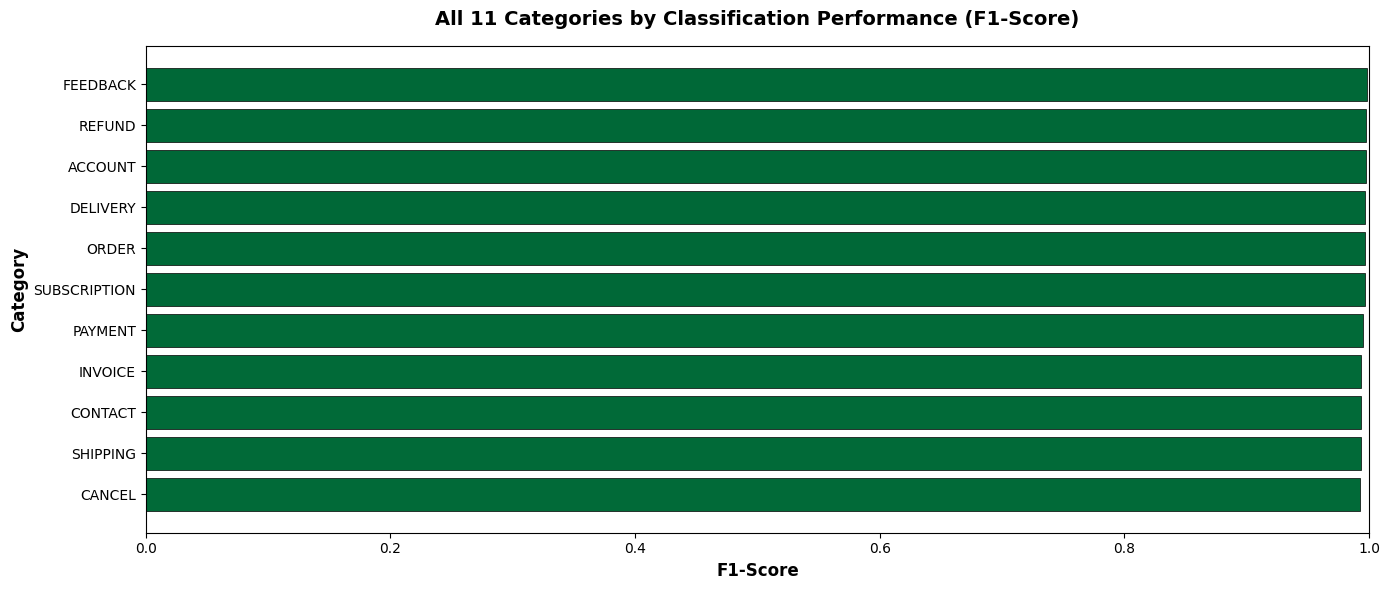

In [44]:
fig, ax = plt.subplots(1, 1, figsize=(14, 6))


# Create color gradient based on performance (red → yellow → green)
colors = plt.cm.RdYlGn(error_analysis['F1-Score'])

# Plot all 11 categories in one chart
ax.barh(error_analysis['Category'], error_analysis['F1-Score'], color=colors, edgecolor='black', linewidth=0.5)

# Labels and title
ax.set_xlabel('F1-Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Category', fontsize=12, fontweight='bold')
ax.set_title('All 11 Categories by Classification Performance (F1-Score)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlim([0, 1])

plt.tight_layout()
plt.savefig('../experiments/category_difficulty.png', dpi=150, bbox_inches='tight')
plt.show()


## Test Real Examples

In [45]:
# Interactive prediction function
def predict_category(text, model=xgb_model, vectorizer=tfidf, encoder=label_encoder):
    """Predict category for new customer query"""
    # Transform text
    text_tfidf = vectorizer.transform([text])
    
    # Predict
    pred_encoded = model.predict(text_tfidf)[0]
    pred_category = encoder.inverse_transform([pred_encoded])[0]
    
    # Get probabilities for top 3
    proba = model.predict_proba(text_tfidf)[0]
    top_3_indices = proba.argsort()[-3:][::-1]
    top_3_categories = encoder.inverse_transform(top_3_indices)
    top_3_probs = proba[top_3_indices]
    
    print(f"Query: '{text}'")
    print(f"\n Predicted Category: {pred_category}")
    print(f"\n Top 3 Predictions:")
    for cat, prob in zip(top_3_categories, top_3_probs):
        print(f"  {cat}: {prob:.2%}")
    print("=" * 60)
    
    return pred_category

# Test with examples
test_queries = [
    "I want to change my shipping address",
    "How do I cancel my subscription?",
    "My payment failed, what should I do?",
    "Track my order please",
    "I am not sure how to solve my issue can you help me",
]

print(" TESTING WITH SAMPLE QUERIES")
print("=" * 60)
for query in test_queries:
    predict_category(query)
    print()

 TESTING WITH SAMPLE QUERIES
Query: 'I want to change my shipping address'

 Predicted Category: SHIPPING

 Top 3 Predictions:
  SHIPPING: 99.90%
  ACCOUNT: 0.02%
  REFUND: 0.01%

Query: 'How do I cancel my subscription?'

 Predicted Category: ORDER

 Top 3 Predictions:
  ORDER: 32.67%
  ACCOUNT: 18.39%
  REFUND: 10.74%

Query: 'My payment failed, what should I do?'

 Predicted Category: PAYMENT

 Top 3 Predictions:
  PAYMENT: 99.93%
  ACCOUNT: 0.02%
  REFUND: 0.01%

Query: 'Track my order please'

 Predicted Category: ORDER

 Top 3 Predictions:
  ORDER: 98.61%
  ACCOUNT: 0.35%
  REFUND: 0.20%

Query: 'I am not sure how to solve my issue can you help me'

 Predicted Category: ACCOUNT

 Top 3 Predictions:
  ACCOUNT: 24.35%
  SHIPPING: 13.08%
  REFUND: 11.65%



In [41]:
idx = 787
test_query = X_test[idx]
print(f"predicted = {predict_category(test_query)}, Actual = {label_encoder.inverse_transform([y_test[idx]])[0]}")

Query: 'i have got to cancel my newsletter subscription'

 Predicted Category: SUBSCRIPTION

 Top 3 Predictions:
  SUBSCRIPTION: 99.93%
  ACCOUNT: 0.02%
  REFUND: 0.01%
predicted = SUBSCRIPTION, Actual = SUBSCRIPTION
